Enter load level (choose from 1/4, 1/2, 3/4, full): full
Selected load level: full (100% of full load)

Transformer and Load Parameters:
Primary (series): R1 = 0.3 Ω, L1 = 0.6 H
Magnetizing branch: Rm = 500.0 Ω, Lm = 100.0 H
Secondary: R2_total = 8.050 Ω, L2_total = 0.0170 H
Mutual Inductance, M = 0.0990 H

--- Full-Load Current Calculation ---
I2_full (secondary, rms) = 12.422 A
I1_full (series branch, rms) = 6.211 A

Per-unit base currents: Primary series = 6.211 A, Secondary = 12.422 A


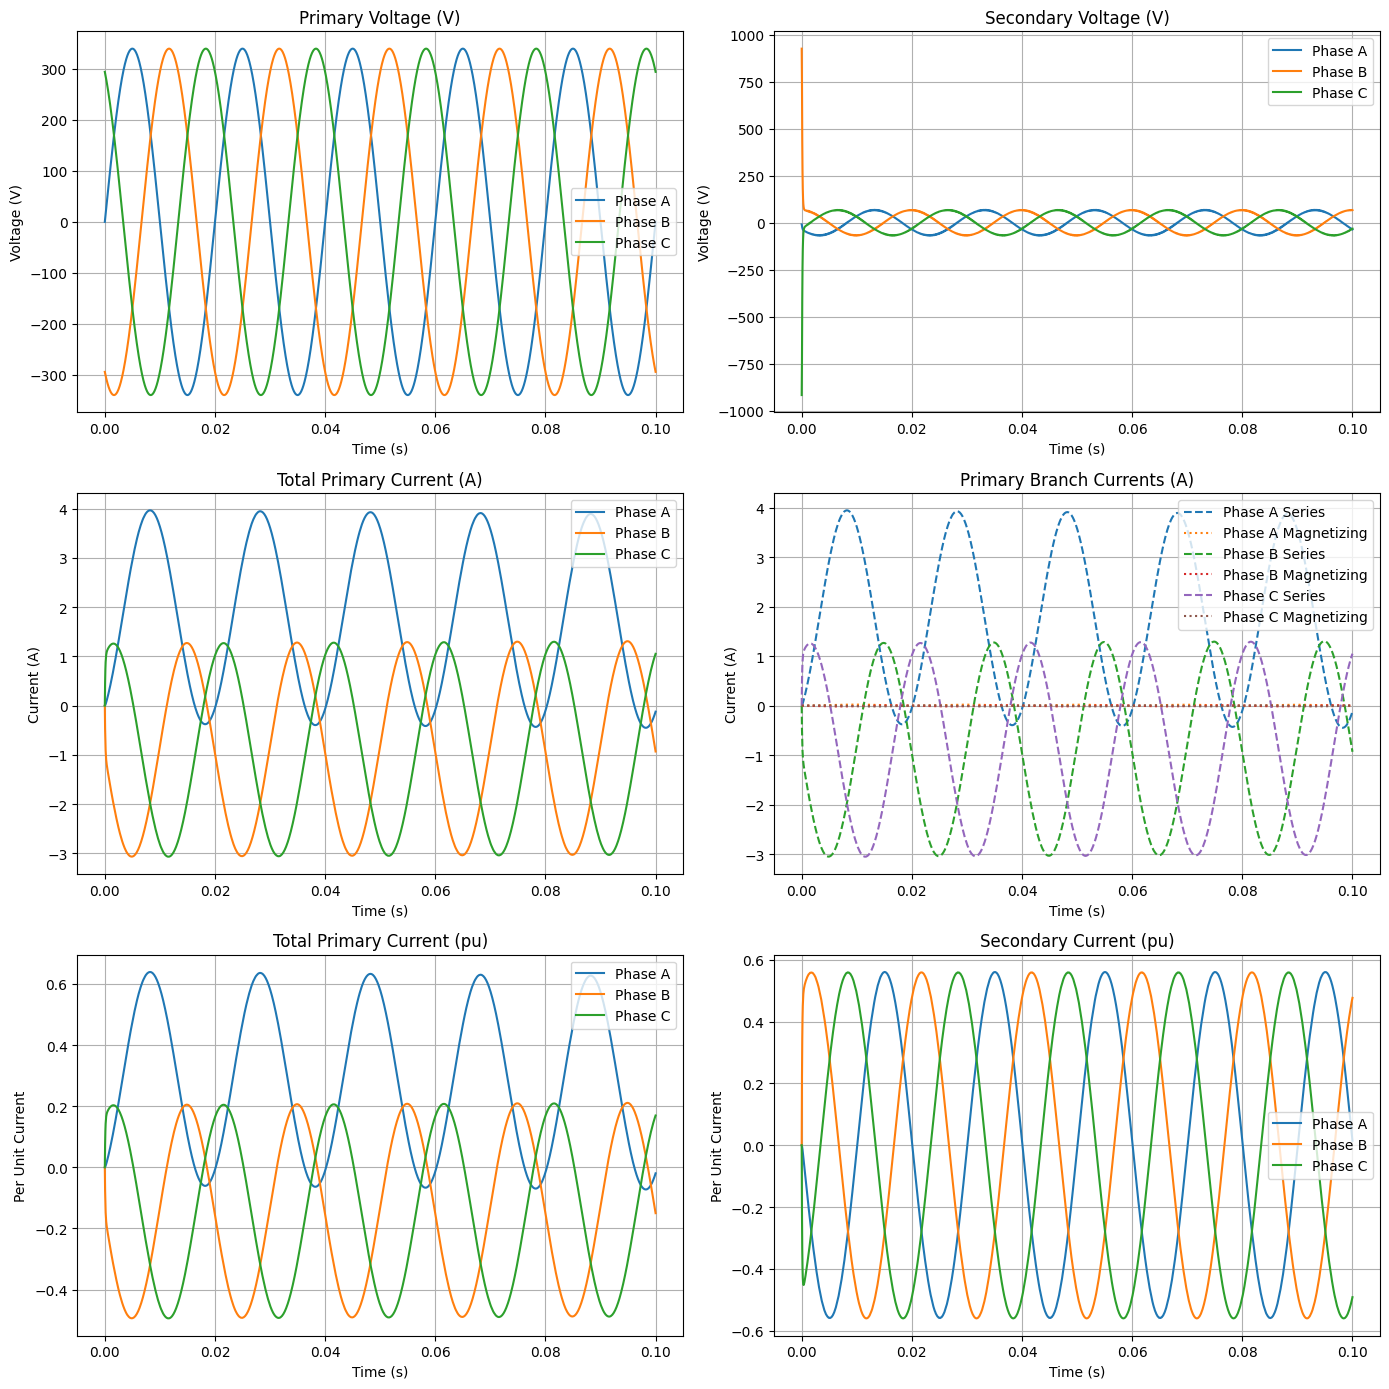

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# -----------------------------------------------
# Prompt for Load Condition
# -----------------------------------------------
valid_loads = ["1/4", "1/2", "3/4", "full"]
load_choice = input("Enter load level (choose from 1/4, 1/2, 3/4, full): ").strip().lower()
while load_choice not in valid_loads:
    load_choice = input("Invalid entry. Enter load level (1/4, 1/2, 3/4, full): ").strip().lower()
if load_choice == "1/4":
    load_multiplier = 0.25
elif load_choice == "1/2":
    load_multiplier = 0.5
elif load_choice == "3/4":
    load_multiplier = 0.75
elif load_choice == "full":
    load_multiplier = 1.0
print(f"Selected load level: {load_choice} ({load_multiplier*100:.0f}% of full load)")
# -----------------------------------------------
# Transformer & Load Parameters (New Values)
# -----------------------------------------------
# Nominal transformer turns (used for setting voltage ratio)
Np_nominal = 1200          # Primary turns (per phase)
Ns_nominal = 600           # Secondary turns (per phase)
turns_ratio = Np_nominal / Ns_nominal  # Should be 2
# Primary winding parameters (non-ideal)
R1 = 0.3       # Primary series branch resistance (ohms)
L1 = 0.6       # Primary series inductance (H)
# Secondary winding (winding only)
R2 = 0.05      # Secondary winding resistance (ohms)
# Secondary leakage and external load nominal parameters (for full load)
L2_leak = 0.015         # Secondary leakage inductance (H)
L_load_nominal = 0.002  # Nominal external load inductance (H)
R_load_nominal = 8.0    # Nominal external load resistance (ohms)
# Scale the external load for load conditions lower than full load:
scale_factor = 1 / load_multiplier
R_load_eff = R_load_nominal * scale_factor
L_load_eff = L_load_nominal * scale_factor
# Total effective secondary series impedance:
R2_total = R2 + R_load_eff
L2_total = L2_leak + L_load_eff
# Shunt (magnetizing) branch parameters
Rm = 500.0    # Magnetizing branch resistance (ohms)
Lm = 100.0    # Magnetizing branch inductance (H)
# Coupling coefficient (practical transformer, < 1)
k = 0.98
# Mutual inductance (depends on L1 and effective secondary inductance)
M = k * math.sqrt(L1 * L2_total)
print("\nTransformer and Load Parameters:")
print(f"Primary (series): R1 = {R1} Ω, L1 = {L1} H")
print(f"Magnetizing branch: Rm = {Rm} Ω, Lm = {Lm} H")
print(f"Secondary: R2_total = {R2_total:.3f} Ω, L2_total = {L2_total:.4f} H")
print(f"Mutual Inductance, M = {M:.4f} H")
# -----------------------------------------------
# Full-Load Current Calculation (for load_multiplier = 1)
# -----------------------------------------------
if load_multiplier == 1.0:
    V1_rms = 240  # Primary phase RMS voltage (V)
    V2_rms = V1_rms / turns_ratio  # Ideal secondary RMS voltage (V)
    f = 50  # Hz
    omega = 2 * math.pi * f
    # Compute secondary impedance at full load:
    Z2_total = complex(R2_total, omega * L2_total)
    absZ2 = abs(Z2_total) # Fixed indentation: This line was not indented correctly
    I2_full = V2_rms / absZ2  # Secondary full-load current (rms)
    I1_full = I2_full / turns_ratio  # Primary series branch current (rms)
    print("\n--- Full-Load Current Calculation ---")
    print(f"I2_full (secondary, rms) = {I2_full:.3f} A")
    print(f"I1_full (series branch, rms) = {I1_full:.3f} A")
else:
    # Compute full-load base currents from nominal full-load values
    V1_rms = 240
    V2_rms = V1_rms / turns_ratio
    f = 50
    omega = 2 * math.pi * f
    R_load_full = R_load_nominal
    L_load_full = L_load_nominal
    R2_full = R2 + R_load_full
    L2_full = L2_leak + L_load_full
    Z2_full = complex(R2_full, omega * L2_full)
    absZ2_full = abs(Z2_full)
    I2_full = V2_rms / absZ2_full
    I1_full = I2_full / turns_ratio
    print("\n(Note: Full-load base currents computed from nominal full-load values)")
    print(f"I2_full (secondary, rms) = {I2_full:.3f} A")
    print(f"I1_full (series branch, rms) = {I1_full:.3f} A")
# Define base currents for per-unit conversion:
I1_base = I1_full  # Base for series branch current (A)
I2_base = I2_full  # Base for secondary current (A)
print(f"\nPer-unit base currents: Primary series = {I1_base:.3f} A, Secondary = {I2_base:.3f} A")
# -----------------------------------------------
# Supply and Simulation Settings
# -----------------------------------------------
V1_peak = V1_rms * math.sqrt(2)
t_start = 0
t_end = 0.1         # seconds (approx. 5 cycles)
t_eval = np.linspace(t_start, t_end, 2000)
# Define phase angles for balanced three-phase supply (line-to-neutral)
phases = {
    'A': 0,
    'B': -120,
    'C': 120
}
# -----------------------------------------------
# Transformer Differential Equations with Shunt (Per Phase)
# -----------------------------------------------
# State vector x: [i1, i_m, i2]
#  i1: current through primary series branch
#  i_m: magnetizing (shunt) current
#  i2: secondary current
#
# Equations:
# (1) Primary series branch: v1 = R1*i1 + L1*di1/dt + M*di2/dt
# (2) Magnetizing branch:    v1 = Rm*i_m + Lm*di_m/dt
# (3) Secondary side:         0 = R2_total*i2 + L2_total*di2/dt + M*di1/dt
def transformer_system_with_shunt(t, x, phase_deg, R1, L1, M, R2_total, L2_total, Rm, Lm):
    phase_rad = np.deg2rad(phase_deg)
    v1 = V1_peak * np.sin(2 * np.pi * f * t + phase_rad)
    i1, i_m, i2 = x
    # For the series branch and secondary, form a 2x2 system:
    # [L1    M      ] [di1/dt] = [v1 - R1*i1]
    # [M  L2_total ] [di2/dt]   [-R2_total*i2]
    A = np.array([[L1, M],
                  [M, L2_total]])
    b = np.array([v1 - R1 * i1,
                  - R2_total * i2])
    det = L1 * L2_total - M**2
    invA = (1/det) * np.array([[L2_total, -M],
                               [-M,       L1]])
    di1_dt, di2_dt = invA @ b
    # Magnetizing branch (shunt):
    di_m_dt = (v1 - Rm * i_m) / Lm
    return [di1_dt, di_m_dt, di2_dt]
# -----------------------------------------------
# Solve the Transformer Model for Each Phase (with Shunt)
# -----------------------------------------------
results = {}
for phase, angle in phases.items():
    sol = solve_ivp(transformer_system_with_shunt, [t_start, t_end], [0, 0, 0],
                    args=(angle, R1, L1, M, R2_total, L2_total, Rm, Lm),
                    t_eval=t_eval, method='RK45')
    results[phase] = sol
# -----------------------------------------------
# Compute Waveforms & Convert to Per-Unit
# -----------------------------------------------
waveforms = {}
for phase, angle in phases.items():
    sol = results[phase]
    t_vals = sol.t
    i1 = sol.y[0]       # Primary series branch current (A)
    i_m = sol.y[1]      # Magnetizing current (A)
    i2 = sol.y[2]       # Secondary current (A)
    # Total primary current drawn from the source:
    i_primary_total = i1 + i_m
    phase_rad = np.deg2rad(angle)
    v_primary = V1_peak * np.sin(2 * np.pi * f * t_vals + phase_rad)
    p_primary = v_primary * i_primary_total
    # Compute secondary voltage using numerical derivative:
    di2_dt = np.gradient(i2, t_vals)
    v_secondary = R2_total * i2 + L2_total * di2_dt
    p_secondary = v_secondary * i2
    # Convert currents to per-unit:
    i1_pu = i1 / I1_base
    i_m_pu = i_m / I1_base   # using same base for primary currents
    i_primary_total_pu = i_primary_total / I1_base
    i2_pu = i2 / I2_base
    waveforms[phase] = {
        'time': t_vals,
        'v_primary': v_primary,
        'i_series': i1,
        'i_magnetizing': i_m,
        'i_primary_total': i_primary_total,
        'i_primary_total_pu': i_primary_total_pu,
        'p_primary': p_primary,
        'v_secondary': v_secondary,
        'i_secondary': i2,
        'i_secondary_pu': i2_pu,
        'p_secondary': p_secondary
    }
# -----------------------------------------------
# Plotting: Voltages and Currents (including Magnetizing branch)
# -----------------------------------------------
plt.figure(figsize=(14, 14))
# Primary Voltage
plt.subplot(3, 2, 1)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['v_primary'], label=f'Phase {phase}')
plt.title("Primary Voltage (V)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()
# Secondary Voltage
plt.subplot(3, 2, 2)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['v_secondary'], label=f'Phase {phase}')
plt.title("Secondary Voltage (V)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()
# Total Primary Current (Actual)
plt.subplot(3, 2, 3)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['i_primary_total'], label=f'Phase {phase}')
plt.title("Total Primary Current (A)")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.grid(True)
plt.legend()
# Breakdown: Series vs Magnetizing Current
plt.subplot(3, 2, 4)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['i_series'], '--', label=f'Phase {phase} Series')
    plt.plot(waveforms[phase]['time'], waveforms[phase]['i_magnetizing'], ':', label=f'Phase {phase} Magnetizing')
plt.title("Primary Branch Currents (A)")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.grid(True)
plt.legend()
# Primary Current in Per Unit
plt.subplot(3, 2, 5)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['i_primary_total_pu'], label=f'Phase {phase}')
plt.title("Total Primary Current (pu)")
plt.xlabel("Time (s)")
plt.ylabel("Per Unit Current")
plt.grid(True)
plt.legend()
# Secondary Current (Per Unit)
plt.subplot(3, 2, 6)
for phase in phases:
    plt.plot(waveforms[phase]['time'], waveforms[phase]['i_secondary_pu'], label=f'Phase {phase}')
plt.title("Secondary Current (pu)")
plt.xlabel("Time (s)")
plt.ylabel("Per Unit Current")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# -----------------------------------------------
# Prompt for Load Condition
# -----------------------------------------------
valid_loads = ["1/4", "1/2", "3/4", "full"]
load_choice = input("Enter load level (choose from 1/4, 1/2, 3/4, full): ").strip().lower()
while load_choice not in valid_loads:
    load_choice = input("Invalid entry. Enter load level (1/4, 1/2, 3/4, full): ").strip().lower()
load_multiplier = {"1/4": 0.25, "1/2": 0.5, "3/4": 0.75, "full": 1.0}[load_choice]
print(f"Selected load level: {load_choice} ({load_multiplier*100:.0f}% of full load)")
# -----------------------------------------------
# Transformer & Load Parameters (New Values)
# -----------------------------------------------
Np_nominal = 1200          # Primary turns (per phase)
Ns_nominal = 600           # Secondary turns (per phase)
turns_ratio = Np_nominal / Ns_nominal
R1 = 0.3  # Primary resistance (ohms)
L1 = 0.6  # Primary inductance (H)
R2 = 0.05 # Secondary resistance (ohms)
L2_leak = 0.015
L_load_nominal = 0.002
R_load_nominal = 8.0
scale_factor = 1 / load_multiplier
R_load_eff = R_load_nominal * scale_factor
L_load_eff = L_load_nominal * scale_factor
R2_total = R2 + R_load_eff
L2_total = L2_leak + L_load_eff
Rm = 500.0  # Magnetizing resistance (ohms)
Lm = 100.0  # Magnetizing inductance (H)
k = 0.98
M = k * math.sqrt(L1 * L2_total)
print("\nTransformer and Load Parameters:")
print(f"Primary (series): R1 = {R1} Ω, L1 = {L1} H")
print(f"Magnetizing branch: Rm = {Rm} Ω, Lm = {Lm} H")
print(f"Secondary: R2_total = {R2_total:.3f} Ω, L2_total = {L2_total:.4f} H")
print(f"Mutual Inductance, M = {M:.4f} H")
# -----------------------------------------------
# Fault Injection
# -----------------------------------------------
fault_types = ["l-g", "l-l-g", "l-l-l-g", "temperature"]
fault_choice = input(f"Enter fault type ({', '.join(fault_types)} or none): ").strip().lower()
if fault_choice == "l-g":
    R1 *= 2  # Increase primary resistance
    print("Injected Line-to-Ground (L-G) fault.")
elif fault_choice == "l-l-g":
    L2_total *= 1.5  # Increase secondary inductance
    print("Injected Line-to-Line-to-Ground (L-L-G) fault.")
elif fault_choice == "l-l-l-g":
    R2_total *= 2  # Increase secondary resistance
    print("Injected Line-to-Line-to-Line-to-Ground (L-L-L-G) fault.")
elif fault_choice == "temperature":
    Rm *= 1.8  # Increase core resistance to simulate overheating
    print("Injected Temperature Fault.")
else:
    print("No fault injected.")
# -----------------------------------------------
# Transformer Differential Equations
# -----------------------------------------------
def transformer_system(t, x, phase_deg, R1, L1, M, R2_total, L2_total, Rm, Lm):
    phase_rad = np.deg2rad(phase_deg)
    v1 = V1_peak * np.sin(2 * np.pi * f * t + phase_rad)
    i1, i_m, i2 = x
    A = np.array([[L1, M],
                  [M, L2_total]])
    b = np.array([v1 - R1 * i1,
                  - R2_total * i2])
    det = L1 * L2_total - M**2
    invA = (1/det) * np.array([[L2_total, -M],
                               [-M,       L1]])
    di1_dt, di2_dt = invA @ b
    di_m_dt = (v1 - Rm * i_m) / Lm
    return [di1_dt, di_m_dt, di2_dt]
# -----------------------------------------------
# Simulation
# -----------------------------------------------
t_start, t_end = 0, 0.1
t_eval = np.linspace(t_start, t_end, 2000)
phases = { 'A': 0, 'B': -120, 'C': 120 }
results = {}
for phase, angle in phases.items():
    sol = solve_ivp(transformer_system, [t_start, t_end], [0, 0, 0],
                    args=(angle, R1, L1, M, R2_total, L2_total, Rm, Lm),
                    t_eval=t_eval, method='RK45')
    results[phase] = sol
# -----------------------------------------------
# Plot Results
# -----------------------------------------------
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
for phase in phases:
    plt.plot(results[phase].t, results[phase].y[0], label=f'Phase {phase}')
plt.title("Primary Current (A)")
plt.legend()
plt.subplot(2, 1, 2)
for phase in phases:
    plt.plot(results[phase].t, results[phase].y[2], label=f'Phase {phase}')
plt.title("Secondary Current (A)")
plt.legend()
plt.show()
